In [24]:
import numpy as np, matplotlib.pyplot as plt

In [25]:
#initializing required parameters
n_cars = 50
l_road = 4*n_cars #3 cars' equivanent space between adjacent cars
initial_spacing = 3
timesteps = 1000
driving_parameter = 2 #denotes rigidity in driving

In [26]:
car_positions = np.linspace(0, l_road - 10, n_cars)  #slight distance left on road for movement
car_positions[25] -= 1

In [27]:
def energy_function(position): #energy will be high for cars that are close
    gaps = np.diff(position, append=position[0]+l_road)
    return(np.sum((gaps - initial_spacing)**2))

In [28]:
history = np.zeros((timesteps, n_cars))
jam_sizes = []

currentEnergy = energy_function(car_positions)

for t in range(timesteps):
    for i in range(n_cars):
        move = np.random.choice([-1, 1])
        new_car_positions = car_positions.copy()
        new_car_positions[i] = (new_car_positions[i]+move) % l_road
        #checking that they do not cross each other or overlap as it is 1D motion
        sorted_pos = np.sort(new_car_positions)
        newEnergy = energy_function(sorted_pos)

        if newEnergy<currentEnergy:
            accept = True
        else:
            prob = np.exp(-driving_parameter * (newEnergy - currentEnergy))
            accept = np.random.random()<prob
        

        if accept:
            car_positions = sorted_pos
            currentEnergy = newEnergy
    
    history[t, :] = car_positions

    gaps = np.diff(car_positions, append=car_positions[0]+l_road)
    jam_size = np.sum(gaps<3)
    jam_sizes.append(jam_size)

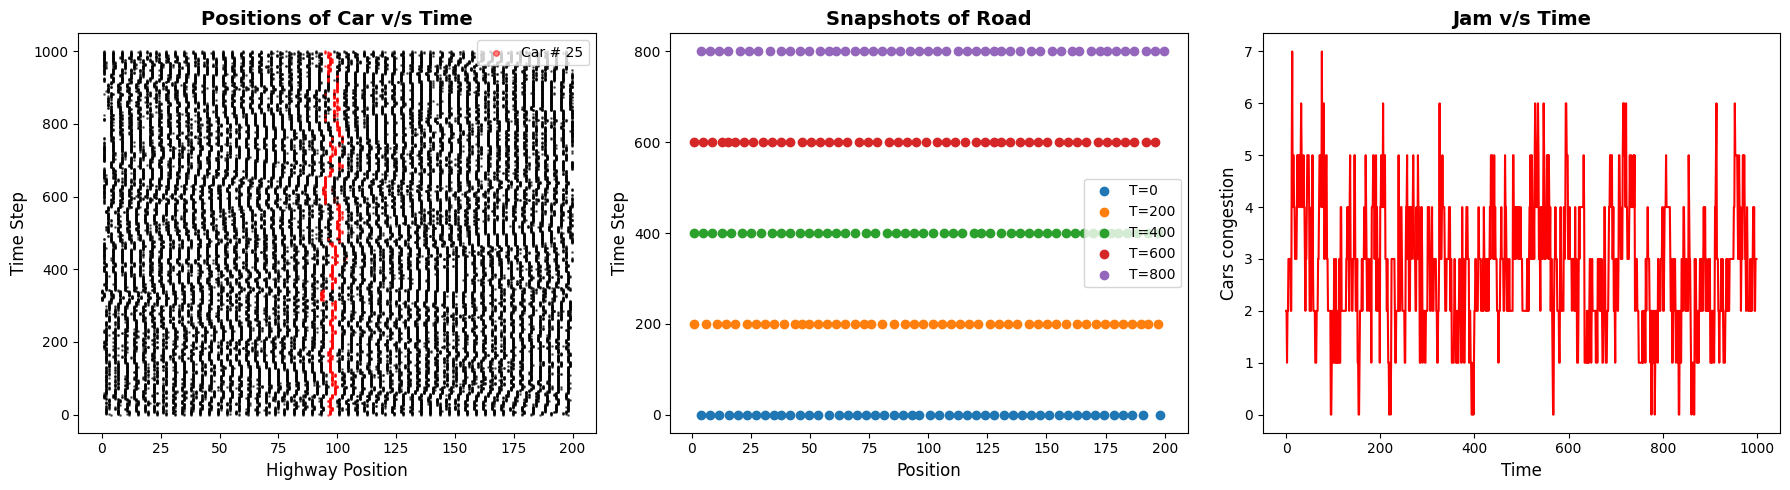

In [29]:
fig, ax = plt.subplots(1, 3, figsize = (18, 5))

for i in range(n_cars):
    if i == 24:
        ax[0].scatter(history[:, i], range(timesteps), s = 1, alpha = 0.5, c = 'red', label = 'Car # 25')
    else:
        ax[0].scatter(history[:, i], range(timesteps), s = 1, alpha = 0.5, c = 'black')
ax[0].set_title("Positions of Car v/s Time", fontsize = 14, fontweight = 'bold')
ax[0].set_xlabel("Highway Position", fontsize = 12)
ax[0].set_ylabel("Time Step", fontsize = 12)
ax[0].legend(loc = 'upper right', markerscale = 4)


time_snapshots = [0, 200, 400, 600,800]
for i, t_s in enumerate(time_snapshots):
    ax[1].scatter(history[t_s, :], [i]*n_cars, label = f"T={t_s}")
ax[1].set_yticks(range(len(time_snapshots)))
ax[1].set_yticklabels(time_snapshots)
ax[1].set_title("Snapshots of Road", fontsize = 14, fontweight = 'bold')
ax[1].set_xlabel("Position", fontsize = 12)
ax[1].set_ylabel("Time Step", fontsize = 12)
ax[1].legend()


ax[2].plot(jam_sizes, c = 'r')
ax[2].set_title("Jam v/s Time", fontsize = 14, fontweight = 'bold')
ax[2].set_xlabel("Time", fontsize = 12)
ax[2].set_ylabel("Cars congestion", fontsize = 12)


plt.tight_layout()
plt.show()

- When the jam forms:
In the model, the jam forms almost immediately after teh first few steps. Because the Metropolis algorithm seels to minimize energy, any local compression of cars, i.e. them getting too close creates a high-energy barrier that takes time to resolve

- How it grows:
The jam typically spreads backward relative to the flow of traffic. This is a "stop and go wave". As car number 25 remains slow, the car behind it (on number 24) must decelerate to avoid high energy penalty of a collision, which in turn forces other cars behind it to slow down, creating a chain reaction.

- MCMC Nuance:
Unlike standard kinematic models, MCMC treats traffic as a thermodynamic system. The driving parameter represents driver's rationality, i.e. higher values make drivers follow spacing rules more strictly